# Saved V5 Kaplan–Meier results and VECM comparison

This notebook assumes the V5 Kaplan–Meier processing has already completed and the monthly KM grids are saved.

It therefore starts from:

```python
load_monthly_km(...)
```

and does **not** rerun raw trade pulls, event extraction, or monthly aggregation.

The workflow:

1. loads the saved monthly KM grids for ETH linear and inverse perpetuals;
2. calculates the KM-estimated percentage reaching 90% basis resolution within 10 seconds;
3. graphs the monthly percentages with confidence intervals;
4. reads the saved VECM results using the same `read_files(...)` calls as the attached Hasbrouck notebook;
5. converts hourly VECM estimates to monthly summaries;
6. compares KM resolution with the responding market's error-correction coefficient and with information leadership;
7. repeats the comparison across VECM aggregation latencies;
8. saves analysis-ready CSV outputs.

## 1. Imports

In [1]:
from pathlib import Path
import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from scipy.stats import pearsonr, spearmanr

from survival_analysis_basis_pipeline_v5 import load_monthly_km
from vecm_hasbrouck3 import *

pd.set_option("display.max_columns", 200)

## 2. Configuration

Set the four KM checkpoint directories to the directories already containing the saved V5 `km/` files.

`load_monthly_km(checkpoint_dir, first=...)` automatically reads the small saved monthly KM CSVs from `checkpoint_dir / "km"`.

In [16]:
# Existing V5 checkpoint directories
ETH_UM_DIR = Path("sa_eth_um")
ETH_CM_DIR = Path("sa_eth_cm")
BTC_UM_DIR = Path("sa_btc_um")
BTC_CM_DIR = Path("sa_btc_cm")

KM_RESOLUTION_PCT = 90
KM_HORIZON_SECONDS = 10

# VECM settings copied from the attached notebook
VECM_START = datetime.datetime(2021, 1, 1)
VECM_END = datetime.datetime(2025, 12, 31)

VECM_AGGS = ["1s", "500ms", "200ms", "100ms", "50ms", "10ms"]
VECM_LAGS = [10]
VECM_INTERVAL = "1H"

VECM_PREFIX = "hasbrouck2"
VECM_UM_FOLDER = r"C:\Users\Julia\Desktop\School files\4th year\Thesis\Thesis-code\vecm_hasbrouck2_um"
VECM_CM_FOLDER = r"C:\Users\Julia\Desktop\School files\4th year\Thesis\Thesis-code\vecm_hasbrouck2_cm"

VECM_MONTHLY_AGGREGATION = "median"

## 3. Load the saved monthly KM grids

This is the only KM input step. No raw trades are downloaded or processed.

In [5]:
btc_um_km_spot = load_monthly_km(BTC_UM_DIR, first="spot")
btc_um_km_perp = load_monthly_km(BTC_UM_DIR, first="perp")

btc_cm_km_spot = load_monthly_km(BTC_CM_DIR, first="spot")
btc_cm_km_perp = load_monthly_km(BTC_CM_DIR, first="perp")

print("BTC linear spot KM rows:", len(btc_um_km_spot))
print("BTC linear perp KM rows:", len(btc_um_km_perp))
print("BTC inverse spot KM rows:", len(btc_cm_km_spot))
print("BTC inverse perp KM rows:", len(btc_cm_km_perp))

BTC linear spot KM rows: 21780
BTC linear perp KM rows: 21780
BTC inverse spot KM rows: 21780
BTC inverse perp KM rows: 21780


In [6]:
def label_km_frame(frame, contract_type, first):
    output = frame.copy()
    output["contract_type"] = contract_type

    if "first" not in output.columns:
        output["first"] = first

    return output


km_all = pd.concat(
    [
        label_km_frame(btc_um_km_spot, "linear", "spot"),
        label_km_frame(btc_um_km_perp, "linear", "perp"),
        label_km_frame(btc_cm_km_spot, "inverse", "spot"),
        label_km_frame(btc_cm_km_perp, "inverse", "perp"),
    ],
    ignore_index=True,
)

km_all.head()

,time_s,survival,ci_lower,ci_upper,period,first,shock_significance,resolution_pct,n_episodes,n_resolved,censoring_share,contract_type
0,0.0,0.999231,0.999064,0.999367,2021-01,spot,0.001,50,129957,123908,0.046546,linear
1,1.0,0.466508,0.463793,0.469218,2021-01,spot,0.001,50,129957,123908,0.046546,linear
2,2.0,0.348631,0.346040,0.351222,2021-01,spot,0.001,50,129957,123908,0.046546,linear
3,3.0,0.291727,0.289258,0.294201,2021-01,spot,0.001,50,129957,123908,0.046546,linear
4,4.0,0.256354,0.253983,0.258731,2021-01,spot,0.001,50,129957,123908,0.046546,linear


In [7]:
def extract_resolution_probability(
    km_grid,
    horizon_seconds=10.0,
    resolution_pct=90,
):
    required = {
        "period",
        "time_s",
        "survival",
        "ci_lower",
        "ci_upper",
    }
    missing = required.difference(km_grid.columns)

    if missing:
        raise ValueError(f"KM grid is missing columns: {sorted(missing)}")

    data = km_grid.copy()

    if "resolution_pct" in data.columns:
        data = data[
            data["resolution_pct"].astype(int).eq(int(resolution_pct))
        ].copy()

    data["time_s"] = pd.to_numeric(data["time_s"], errors="coerce")
    data = data.dropna(
        subset=["period", "time_s", "survival", "ci_lower", "ci_upper"]
    )

    group_columns = [
        column
        for column in [
            "period",
            "contract_type",
            "first",
            "shock_significance",
            "resolution_pct",
        ]
        if column in data.columns
    ]

    rows = []

    for group_key, group in data.groupby(
        group_columns,
        dropna=False,
        observed=True,
    ):
        if not isinstance(group_key, tuple):
            group_key = (group_key,)

        group = group.sort_values("time_s")

        # KM is a right-continuous step function. Use the last saved estimate
        # at or before the requested horizon.
        eligible = group[group["time_s"] <= horizon_seconds]

        if eligible.empty:
            continue

        horizon_row = eligible.iloc[-1]
        survival = float(horizon_row["survival"])
        survival_lower = float(horizon_row["ci_lower"])
        survival_upper = float(horizon_row["ci_upper"])

        result = dict(zip(group_columns, group_key))
        result.update(
            {
                "horizon_seconds": float(horizon_seconds),
                "survival_at_horizon": survival,
                "resolved_share": 1.0 - survival,
                "resolved_ci_lower": 1.0 - survival_upper,
                "resolved_ci_upper": 1.0 - survival_lower,
                "resolved_percent": 100.0 * (1.0 - survival),
                "resolved_ci_lower_percent": 100.0 * (1.0 - survival_upper),
                "resolved_ci_upper_percent": 100.0 * (1.0 - survival_lower),
            }
        )

        for column in ["n_episodes", "n_resolved", "censoring_share"]:
            if column in group.columns:
                result[column] = horizon_row[column]

        rows.append(result)

    output = pd.DataFrame(rows)

    if not output.empty:
        output["period"] = output["period"].astype(str)
        output["month"] = pd.to_datetime(
            output["period"],
            format="%Y-%m",
            errors="coerce",
        )

    return output

In [8]:
km_10s = extract_resolution_probability(
    km_all,
    horizon_seconds=1,
    resolution_pct=KM_RESOLUTION_PCT,
)

km_10s.sort_values(
    ["contract_type", "first", "month"]
).head(12)

,period,contract_type,first,shock_significance,resolution_pct,horizon_seconds,survival_at_horizon,resolved_share,resolved_ci_lower,resolved_ci_upper,resolved_percent,resolved_ci_lower_percent,resolved_ci_upper_percent,n_episodes,n_resolved,censoring_share,month
0,2021-01,inverse,perp,0.001,90,1.0,0.886762,0.113238,0.110908,0.115614,11.323814,11.090810,11.561388,69685,58159,0.165401,2021-01-01
4,2021-02,inverse,perp,0.001,90,1.0,0.844561,0.155439,0.152748,0.158173,15.543883,15.274756,15.817295,68535,59420,0.132998,2021-02-01
8,2021-03,inverse,perp,0.001,90,1.0,0.791814,0.208186,0.205506,0.210897,20.818607,20.550550,21.089678,87148,77827,0.106956,2021-03-01
12,2021-04,inverse,perp,0.001,90,1.0,0.723393,0.276607,0.273176,0.280073,27.660726,27.317613,28.007273,64644,58767,0.090913,2021-04-01
16,2021-05,inverse,perp,0.001,90,1.0,0.836506,0.163494,0.160789,0.166241,16.349444,16.078916,16.624059,70718,60409,0.145776,2021-05-01
20,2021-06,inverse,perp,0.001,90,1.0,0.809161,0.190839,0.187715,0.194008,19.083868,18.771457,19.400834,59904,52843,0.117872,2021-06-01
24,2021-07,inverse,perp,0.001,90,1.0,0.729301,0.270699,0.266840,0.274603,27.069925,26.684021,27.460306,50340,45481,0.096524,2021-07-01
28,2021-08,inverse,perp,0.001,90,1.0,0.666147,0.333853,0.329714,0.338029,33.385263,32.971409,33.802909,49426,45491,0.079614,2021-08-01
32,2021-09,inverse,perp,0.001,90,1.0,0.685090,0.314910,0.310876,0.318983,31.490990,31.087626,31.898297,50443,45951,0.089051,2021-09-01
36,2021-10,inverse,perp,0.001,90,1.0,0.678796,0.321204,0.317666,0.324771,32.120418,31.766644,32.477130,66369,60565,0.087450,2021-10-01


## 5. Graph the monthly percentage resolved within 10 seconds

In [9]:
def plot_resolution_within_horizon(
    resolution_summary,
    horizon_seconds=10,
    resolution_pct=90,
):
    data = resolution_summary.dropna(
        subset=[
            "month",
            "resolved_percent",
            "resolved_ci_lower_percent",
            "resolved_ci_upper_percent",
        ]
    ).copy()

    contract_types = [
        contract
        for contract in ["linear", "inverse"]
        if contract in data["contract_type"].unique()
    ]

    fig, axes = plt.subplots(
        len(contract_types),
        1,
        figsize=(12, 4.5 * len(contract_types)),
        sharex=True,
        squeeze=False,
    )

    for axis, contract_type in zip(axes[:, 0], contract_types):
        contract_data = data[
            data["contract_type"].eq(contract_type)
        ]

        for first, group in contract_data.groupby("first", observed=True):
            group = group.sort_values("month")

            line = axis.plot(
                group["month"],
                group["resolved_percent"],
                marker="o",
                markersize=3,
                linewidth=1.5,
                label=f"{first}-originating shocks",
            )[0]

            axis.fill_between(
                group["month"],
                group["resolved_ci_lower_percent"],
                group["resolved_ci_upper_percent"],
                alpha=0.15,
                color=line.get_color(),
            )

        axis.set_title(f"{contract_type.capitalize()} perpetual")
        axis.set_ylabel(f"Resolved within {horizon_seconds:g}s (%)")
        axis.set_ylim(0, 100)
        axis.grid(axis="y", alpha=0.3)
        axis.legend()

    axes[-1, 0].set_xlabel("Month")
    axes[-1, 0].xaxis.set_major_locator(mdates.YearLocator())
    axes[-1, 0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    fig.suptitle(
        f"KM-estimated share reaching {resolution_pct}% basis resolution "
        f"within {horizon_seconds:g} seconds",
        y=1.01,
    )

    fig.tight_layout()
    plt.show()

In [10]:
HORIZONS_SECONDS = [1, 2, 5, 10]
RESOLUTION_PCT = 90

# Extract monthly KM resolution probabilities at each horizon.
km_horizons = pd.concat(
    [
        extract_resolution_probability(
            km_all,
            horizon_seconds=horizon,
            resolution_pct=RESOLUTION_PCT,
        ).assign(horizon_seconds=horizon)
        for horizon in HORIZONS_SECONDS
    ],
    ignore_index=True,
)

# Determine the calendar year.
date_column = next(
    (
        column
        for column in [
            "month",
            "period",
            "period_start",
        ]
        if column in km_horizons.columns
    ),
    None,
)

if date_column is None:
    raise KeyError(
        "No monthly date column was found."
    )

km_horizons["year"] = pd.to_datetime(
    km_horizons[date_column]
).dt.year

# Average the monthly KM estimates within each year.
annual_resolution = (
    km_horizons
    .groupby(
        [
            "year",
            "contract_type",
            "first",
            "horizon_seconds",
        ],
        observed=True,
        as_index=False,
    )
    .agg(
        average_resolved_percent=(
            "resolved_percent",
            "mean",
        ),
        median_resolved_percent=(
            "resolved_percent",
            "median",
        ),
        n_months=(
            "resolved_percent",
            "count",
        ),
    )
)

# Present one row per year, contract, and origin.
annual_resolution_wide = (
    annual_resolution
    .pivot(
        index=[
            "year",
            "contract_type",
            "first",
        ],
        columns="horizon_seconds",
        values="average_resolved_percent",
    )
    .rename(
        columns={
            1: "resolved_by_1s_pct",
            2: "resolved_by_2s_pct",
            5: "resolved_by_5s_pct",
            10: "resolved_by_10s_pct",
        }
    )
    .reset_index()
)

display(annual_resolution_wide)

horizon_seconds,year,contract_type,first,resolved_by_1s_pct,resolved_by_2s_pct,resolved_by_5s_pct,resolved_by_10s_pct
0,2021,inverse,perp,25.628908,34.775701,48.779722,60.459381
1,2021,inverse,spot,29.604339,42.535177,62.704343,77.134776
2,2021,linear,perp,41.991304,57.336915,74.830585,83.784607
3,2021,linear,spot,37.661739,51.004909,67.370488,76.858195
4,2022,inverse,perp,23.911908,31.578509,43.449195,53.529395
5,2022,inverse,spot,30.828931,40.678975,56.709949,69.869672
6,2022,linear,perp,44.479123,57.290837,72.897772,82.126128
7,2022,linear,spot,38.223224,49.107106,63.275664,72.196749
8,2023,inverse,perp,25.408310,31.399303,40.900805,49.490437
9,2023,inverse,spot,44.603979,51.785784,62.468513,71.286367


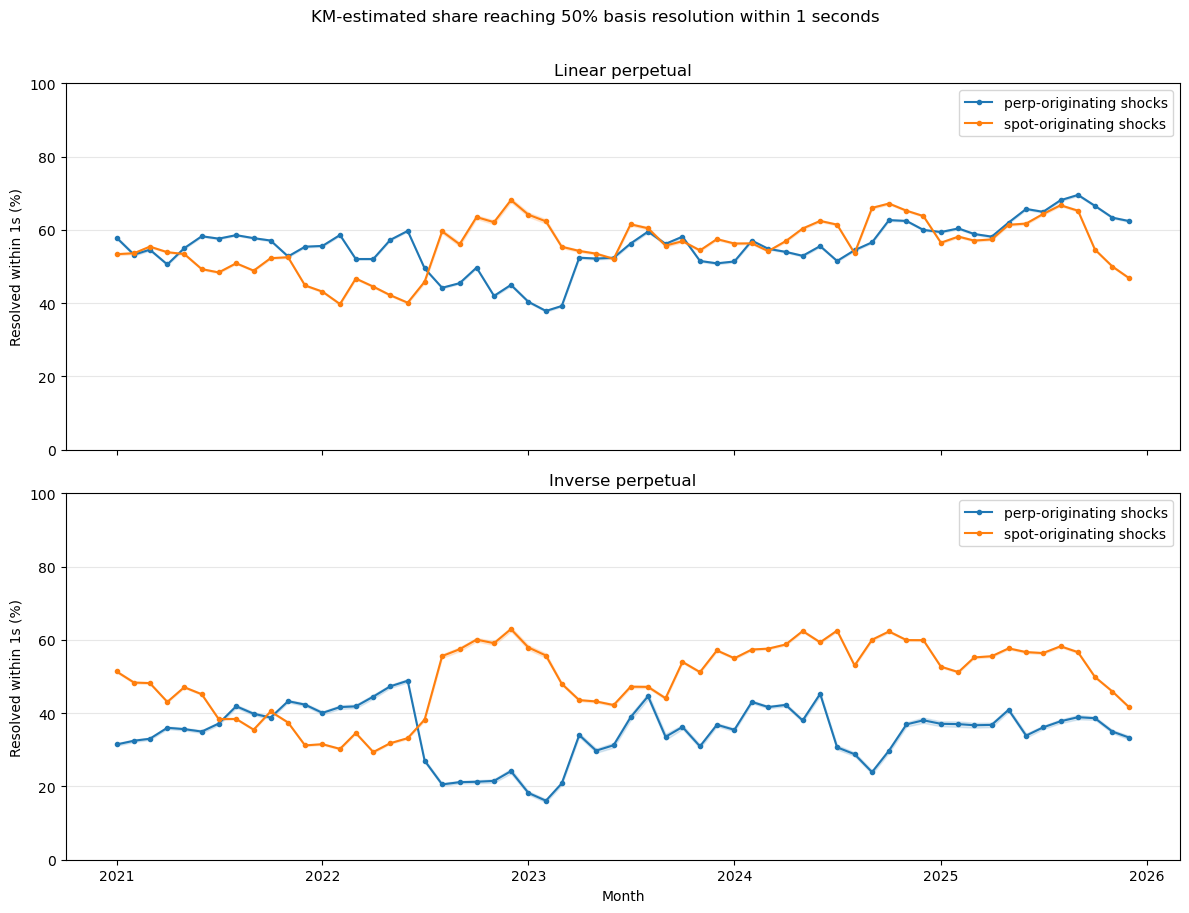

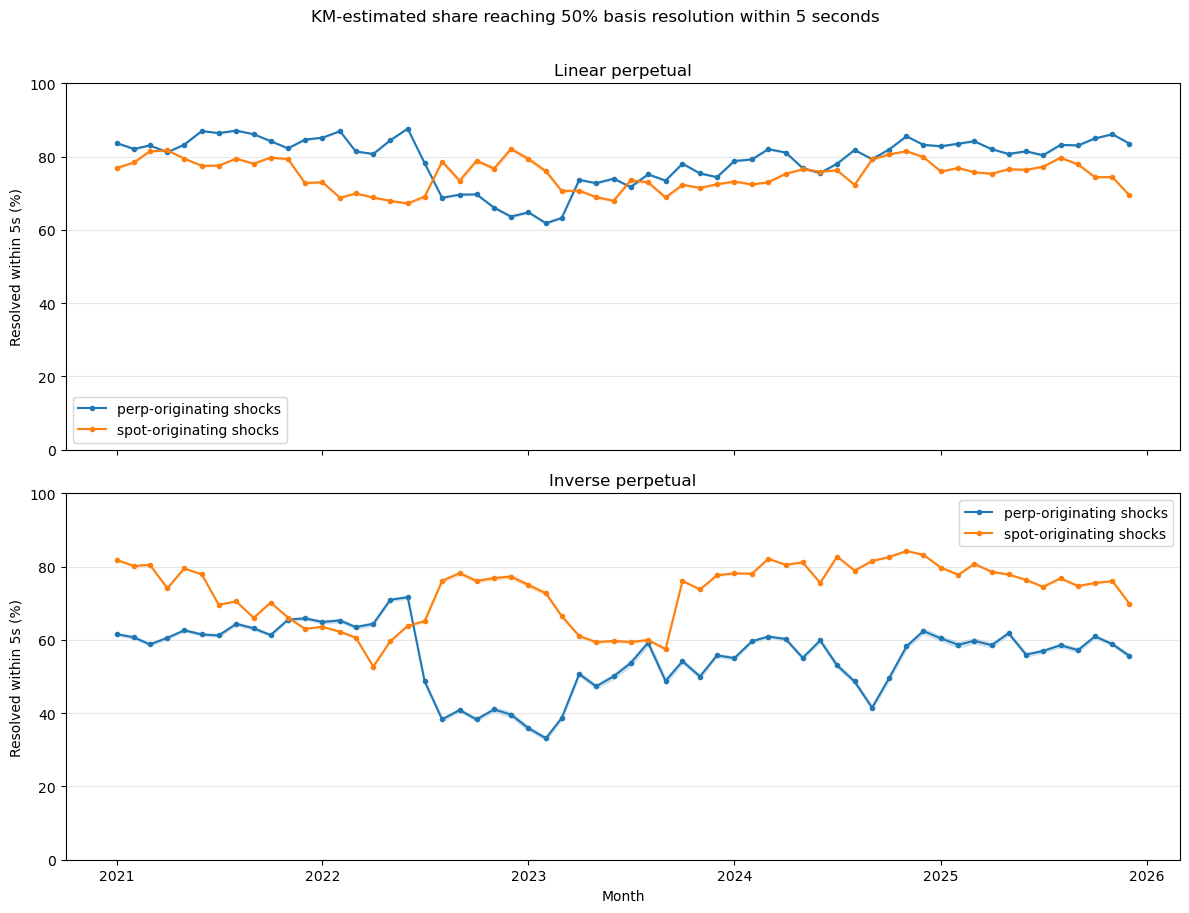

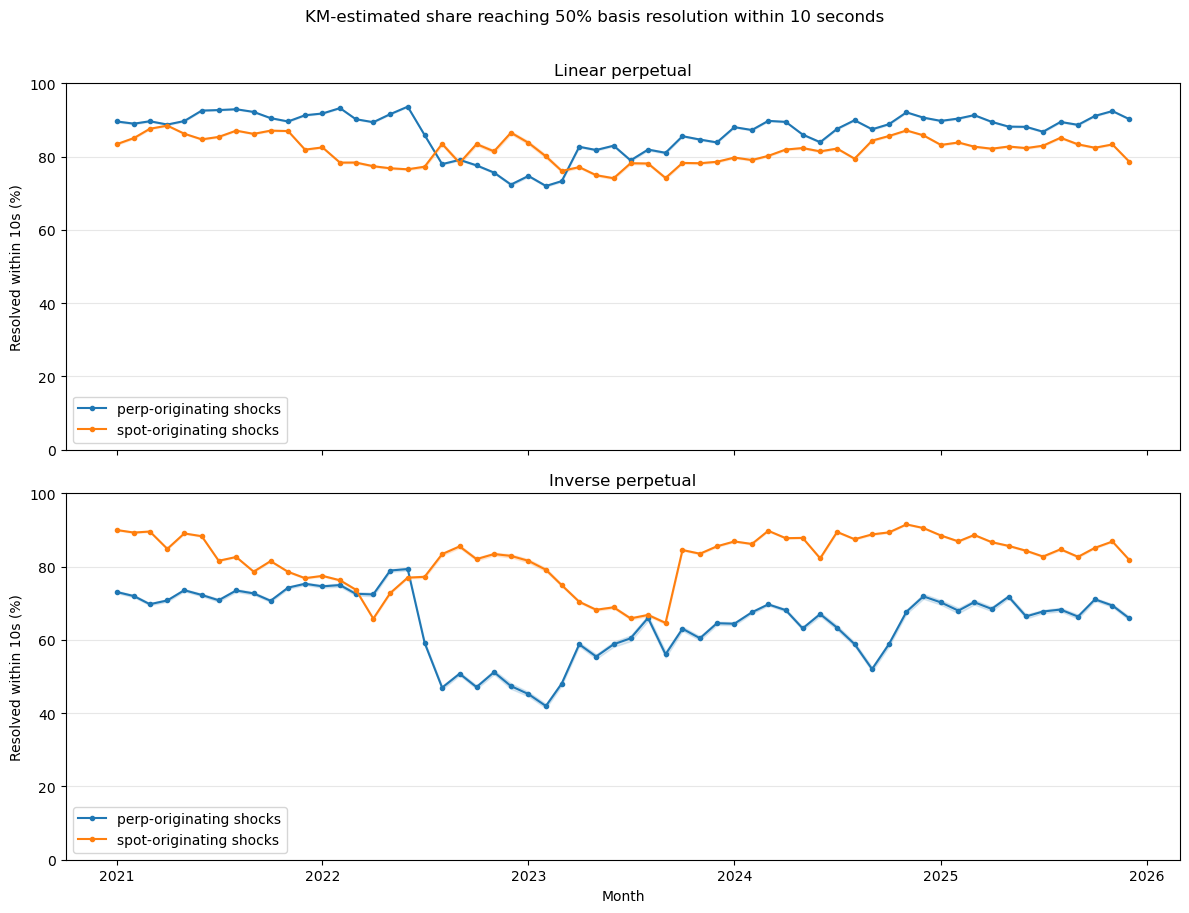

In [11]:
km_10s = extract_resolution_probability(
    km_all,
    horizon_seconds=1,
    resolution_pct=50,
)

plot_resolution_within_horizon(
    km_10s,
    horizon_seconds=1,
    resolution_pct=50,
)

km_10s = extract_resolution_probability(
    km_all,
    horizon_seconds=5,
    resolution_pct=50,
)

plot_resolution_within_horizon(
    km_10s,
    horizon_seconds=5,
    resolution_pct=50,
)

km_10s = extract_resolution_probability(
    km_all,
    horizon_seconds=10,
    resolution_pct=50,
)

plot_resolution_within_horizon(
    km_10s,
    horizon_seconds=10,
    resolution_pct=50,
)

In [17]:
linear_res_dict = read_files(
    VECM_START,
    VECM_END,
    VECM_AGGS,
    VECM_INTERVAL,
    VECM_LAGS,
    "um",
    VECM_PREFIX,
    VECM_UM_FOLDER,
)

inverse_res_dict = read_files(
    VECM_START,
    VECM_END,
    VECM_AGGS,
    VECM_INTERVAL,
    VECM_LAGS,
    "cm",
    VECM_PREFIX,
    VECM_CM_FOLDER,
)

print("Linear result keys:", sorted(linear_res_dict.keys()))
print("Inverse result keys:", sorted(inverse_res_dict.keys()))

Linear result keys: [('100ms', 10), ('1s', 10), ('200ms', 10), ('500ms', 10)]
Inverse result keys: [('100ms', 10), ('1s', 10), ('200ms', 10), ('500ms', 10), ('50ms', 10)]


## 7. Convert hourly VECM results to monthly values

The VECM files contain one row for `log_midpoint_spot` and one row for `log_midpoint_perp` in each hourly interval. The function below:

1. removes duplicate interval-series estimates, preferring the row with more observations;
2. pivots spot and perp estimates into one row;
3. takes the monthly median or mean.

The median is the default because hourly alpha and share estimates can contain extreme values.

## 6. Read all saved VECM latency–lag combinations

The VECM dictionaries are keyed by `(latency, lag_base)`. This workflow uses every shared combination in the linear and inverse result dictionaries rather than selecting a primary case.

In [18]:
linear_res_dict = read_files(
    VECM_START, VECM_END, VECM_AGGS, VECM_INTERVAL,
    VECM_LAGS, "um", VECM_PREFIX, VECM_UM_FOLDER,
)

inverse_res_dict = read_files(
    VECM_START, VECM_END, VECM_AGGS, VECM_INTERVAL,
    VECM_LAGS, "cm", VECM_PREFIX, VECM_CM_FOLDER,
)

available_combinations = sorted(
    set(linear_res_dict).intersection(inverse_res_dict)
)

if not available_combinations:
    raise RuntimeError("No shared latency–lag combinations were found.")

available_combinations

[('100ms', 10), ('1s', 10), ('200ms', 10), ('500ms', 10)]

## 7. Convert one VECM combination to monthly values

In [19]:
def prepare_monthly_vecm_results(
    results_dict,
    contract_type,
    latency,
    lag_base=10,
    monthly_aggregation="median",
):
    key = (latency, lag_base)

    if key not in results_dict:
        raise KeyError(
            f"{key} was not found. Available keys: "
            f"{sorted(results_dict.keys())}"
        )

    raw = results_dict[key].copy()
    raw["interval"] = pd.to_datetime(raw["interval"], errors="coerce")
    raw = raw.dropna(subset=["interval"])

    expected_series = {
        "log_midpoint_spot",
        "log_midpoint_perp",
    }
    actual_series = set(raw["series"].dropna().astype(str).unique())
    missing_series = expected_series.difference(actual_series)

    if missing_series:
        raise ValueError(
            f"Missing VECM series: {sorted(missing_series)}. "
            f"Observed series include: {sorted(actual_series)}"
        )

    duplicate_keys = ["interval", "series"]

    if "n_obs" in raw.columns:
        raw = (
            raw.sort_values(
                duplicate_keys + ["n_obs"],
                ascending=[True, True, False],
            )
            .drop_duplicates(duplicate_keys, keep="first")
        )
    else:
        raw = raw.drop_duplicates(duplicate_keys, keep="first")

    value_columns = [
        column
        for column in [
            "alpha",
            "CS",
            "HIS_lower",
            "HIS_upper",
            "HIS_mid",
            "ILS_mid",
            "n_obs",
        ]
        if column in raw.columns
    ]

    wide = raw.pivot_table(
        index="interval",
        columns="series",
        values=value_columns,
        aggfunc="first",
    )

    wide.columns = [
        f"{metric}_{series.replace('log_midpoint_', '')}"
        for metric, series in wide.columns
    ]
    wide = wide.reset_index()

    wide["month"] = wide["interval"].dt.to_period("M").dt.to_timestamp()
    wide["period"] = wide["month"].dt.strftime("%Y-%m")
    wide["contract_type"] = contract_type
    wide["latency"] = latency
    wide["lag_base"] = lag_base

    identifier_columns = {
        "interval",
        "month",
        "period",
        "contract_type",
        "latency",
        "lag_base",
    }
    numeric_columns = [
        column
        for column in wide.columns
        if column not in identifier_columns
    ]

    grouped = wide.groupby(
        ["period", "month", "contract_type", "latency", "lag_base"],
        as_index=False,
        observed=True,
    )[numeric_columns]

    if monthly_aggregation == "median":
        monthly = grouped.median()
    elif monthly_aggregation == "mean":
        monthly = grouped.mean()
    else:
        raise ValueError(
            "monthly_aggregation must be 'median' or 'mean'."
        )

    if "ILS_mid_spot" in monthly.columns:
        monthly["ILS_spot"] = monthly["ILS_mid_spot"]

    if "ILS_mid_perp" in monthly.columns:
        monthly["ILS_perp"] = monthly["ILS_mid_perp"]

    if "alpha_spot" in monthly.columns:
        monthly["abs_alpha_spot"] = monthly["alpha_spot"].abs()

    if "alpha_perp" in monthly.columns:
        monthly["abs_alpha_perp"] = monthly["alpha_perp"].abs()

    return monthly

## 8. Build monthly VECM results for every combination

In [20]:
vecm_frames = []

for latency, lag_base in available_combinations:
    vecm_frames.append(
        prepare_monthly_vecm_results(
            linear_res_dict,
            contract_type="linear",
            latency=latency,
            lag_base=lag_base,
            monthly_aggregation=VECM_MONTHLY_AGGREGATION,
        )
    )
    vecm_frames.append(
        prepare_monthly_vecm_results(
            inverse_res_dict,
            contract_type="inverse",
            latency=latency,
            lag_base=lag_base,
            monthly_aggregation=VECM_MONTHLY_AGGREGATION,
        )
    )

vecm_monthly_all = pd.concat(vecm_frames, ignore_index=True)

vecm_monthly_all[
    ["contract_type", "latency", "lag_base"]
].drop_duplicates().sort_values(
    ["lag_base", "latency", "contract_type"]
)

,contract_type,latency,lag_base
60,inverse,100ms,10
0,linear,100ms,10
180,inverse,1s,10
120,linear,1s,10
300,inverse,200ms,10
240,linear,200ms,10
420,inverse,500ms,10
360,linear,500ms,10


## 9. Merge the fixed KM outcome with every VECM combination

In [21]:
comparison_all = km_10s.merge(
    vecm_monthly_all,
    on=["period", "month", "contract_type"],
    how="inner",
)

comparison_all["responding_alpha"] = np.where(
    comparison_all["first"].eq("spot"),
    comparison_all["alpha_perp"],
    comparison_all["alpha_spot"],
)

comparison_all["abs_responding_alpha"] = (
    comparison_all["responding_alpha"].abs()
)

if {"ILS_spot", "ILS_perp"}.issubset(comparison_all.columns):
    comparison_all["origin_market_ILS"] = np.where(
        comparison_all["first"].eq("spot"),
        comparison_all["ILS_spot"],
        comparison_all["ILS_perp"],
    )

comparison_all.head()

,period,contract_type,first,shock_significance,resolution_pct,horizon_seconds,survival_at_horizon,resolved_share,resolved_ci_lower,resolved_ci_upper,resolved_percent,resolved_ci_lower_percent,resolved_ci_upper_percent,n_episodes,n_resolved,censoring_share,month,latency,lag_base,CS_perp,CS_spot,HIS_lower_perp,HIS_lower_spot,HIS_mid_perp,HIS_mid_spot,HIS_upper_perp,HIS_upper_spot,ILS_mid_perp,ILS_mid_spot,alpha_perp,alpha_spot,n_obs_perp,n_obs_spot,ILS_spot,ILS_perp,abs_alpha_spot,abs_alpha_perp,responding_alpha,abs_responding_alpha,origin_market_ILS
0,2021-01,inverse,perp,0.001,50,10.0,0.268924,0.731076,0.727779,0.734363,73.107555,72.777869,73.436280,69685,65595,0.058693,2021-01-01,100ms,10,0.176071,0.823929,0.028488,0.971512,0.082503,0.917497,0.132451,0.867549,0.294661,0.705339,0.010833,-0.002703,35899.0,35899.0,0.705339,0.294661,0.002703,0.010833,-0.002703,0.002703,0.294661
1,2021-01,inverse,perp,0.001,50,10.0,0.268924,0.731076,0.727779,0.734363,73.107555,72.777869,73.436280,69685,65595,0.058693,2021-01-01,1s,10,0.024341,0.975659,0.006317,0.993683,0.215674,0.784326,0.421710,0.578290,0.669180,0.330820,0.101241,-0.002035,3589.0,3589.0,0.330820,0.669180,0.002035,0.101241,-0.002035,0.002035,0.669180
2,2021-01,inverse,perp,0.001,50,10.0,0.268924,0.731076,0.727779,0.734363,73.107555,72.777869,73.436280,69685,65595,0.058693,2021-01-01,200ms,10,0.173569,0.826431,0.021248,0.978752,0.119307,0.880693,0.212633,0.787367,0.396541,0.603459,0.020450,-0.004484,17949.0,17949.0,0.603459,0.396541,0.004484,0.020450,-0.004484,0.004484,0.396541
3,2021-01,inverse,perp,0.001,50,10.0,0.268924,0.731076,0.727779,0.734363,73.107555,72.777869,73.436280,69685,65595,0.058693,2021-01-01,500ms,10,0.072978,0.927022,0.008183,0.991817,0.149692,0.850308,0.277053,0.722947,0.550903,0.449097,0.046220,-0.003638,7179.0,7179.0,0.449097,0.550903,0.003638,0.046220,-0.003638,0.003638,0.550903
4,2021-01,inverse,spot,0.001,50,10.0,0.099760,0.900240,0.898665,0.901802,90.024027,89.866495,90.180164,140257,138414,0.013140,2021-01-01,100ms,10,0.176071,0.823929,0.028488,0.971512,0.082503,0.917497,0.132451,0.867549,0.294661,0.705339,0.010833,-0.002703,35899.0,35899.0,0.705339,0.294661,0.002703,0.010833,0.010833,0.010833,0.705339


## 10. Plot every latency–lag combination

In [22]:
import math


def plot_linear_spot_latency_panels(
    comparison,
    lag_base=10,
    latencies=None,
    columns=3,
    x_column="abs_responding_alpha",
    y_column="resolved_percent",
):
    data = comparison[
        comparison["contract_type"].eq("linear")
        & comparison["first"].eq("spot")
        & comparison["lag_base"].eq(lag_base)
    ].dropna(
        subset=[x_column, y_column, "latency"]
    ).copy()

    if latencies is None:
        latencies = data["latency"].drop_duplicates().tolist()
    else:
        data = data[
            data["latency"].isin(latencies)
        ].copy()

    if data.empty:
        print("No matching observations.")
        return None, None

    ncols = min(columns, len(latencies))
    nrows = math.ceil(len(latencies) / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4.5 * ncols, 3.8 * nrows),
        sharey=True,
        squeeze=False,
    )

    axes_flat = axes.ravel()

    for index, latency in enumerate(latencies):
        ax = axes_flat[index]

        group = data[
            data["latency"].eq(latency)
        ].sort_values(x_column)

        ax.scatter(
            group[x_column],
            group[y_column],
            alpha=0.45,
            s=28,
        )

        valid = group[
            [x_column, y_column]
        ].dropna()

        if len(valid) >= 3:
            slope, intercept = np.polyfit(
                valid[x_column],
                valid[y_column],
                1,
            )

            x_fit = np.linspace(
                valid[x_column].min(),
                valid[x_column].max(),
                100,
            )

            ax.plot(
                x_fit,
                intercept + slope * x_fit,
                linewidth=2.5,
            )

            correlation = valid[
                x_column
            ].corr(
                valid[y_column],
                method="spearman",
            )

            ax.text(
                0.04,
                0.94,
                rf"$\rho_s={correlation:.2f}$",
                transform=ax.transAxes,
                ha="left",
                va="top",
            )

        ax.set_title(str(latency))
        ax.set_ylim(0, 100)
        ax.grid(alpha=0.25)

        if index % ncols == 0:
            ax.set_ylabel("Resolved within 10 seconds (%)")

        if index // ncols == nrows - 1:
            ax.set_xlabel("Absolute responding-market alpha")

    for index in range(len(latencies), len(axes_flat)):
        fig.delaxes(axes_flat[index])

    fig.suptitle(
        "Linear perpetual, spot-originating shocks "
        f"(lag base {lag_base})",
        y=1.01,
    )

    fig.tight_layout()
    plt.show()

    return fig, axes

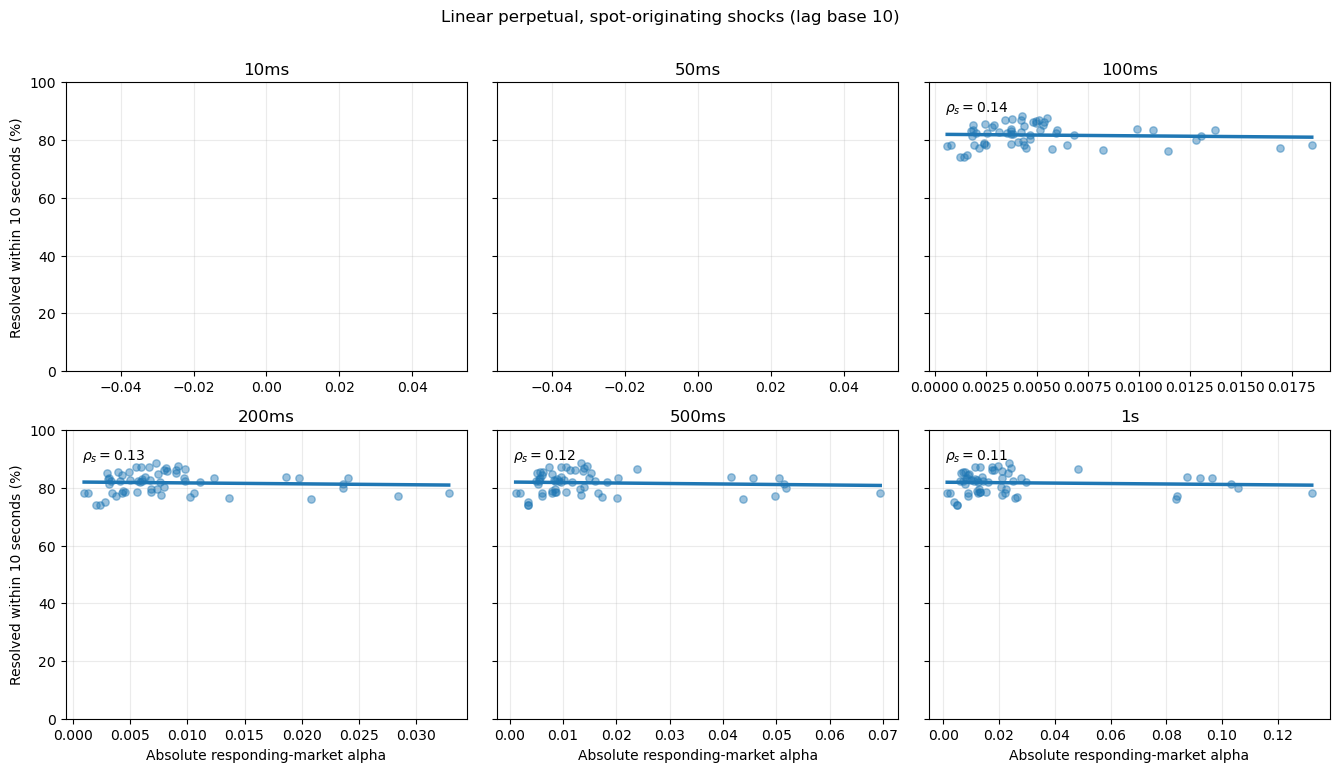

In [23]:
fig, axes = plot_linear_spot_latency_panels(
    comparison_all,
    lag_base=10,
    latencies=[
        "10ms",
        "50ms",
        "100ms",
        "200ms",
        "500ms",
        "1s",
    ],
    columns=3,
)

In [24]:
def plot_vecm_combinations_grid(
    comparison,
    combinations,
    contract_types=("linear", "inverse"),
    x_column="abs_responding_alpha",
    y_column="resolved_percent",
    share_x=False,
):
    """
    One row per (latency, lag_base) pair and one column per contract type.

    Column 1: linear perpetual
    Column 2: inverse perpetual

    There is no maximum number of rows.
    """
    combinations = sorted(
        list(combinations),
        key=lambda pair: (
            latency_to_seconds(pair[0]),
            pair[1],
        ),
    )

    if not combinations:
        raise ValueError(
            "Provide at least one (latency, lag_base) combination."
        )
        
    available_contracts = [
        contract_type
        for contract_type in contract_types
        if contract_type
        in comparison["contract_type"].dropna().unique()
    ]

    if not available_contracts:
        raise ValueError(
            "None of the requested contract types appear in comparison."
        )

    nrows = len(combinations)
    ncols = len(available_contracts)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(6 * ncols, 4.2 * nrows),
        sharex=share_x,
        sharey=True,
        squeeze=False,
    )

    origin_styles = {
        "spot": {
            "marker": "o",
            "linestyle": "-",
        },
        "perp": {
            "marker": "s",
            "linestyle": "--",
        },
    }

    for row_index, (latency, lag_base) in enumerate(combinations):
        combination_data = comparison[
            comparison["latency"].eq(latency)
            & comparison["lag_base"].eq(lag_base)
        ].dropna(
            subset=[x_column, y_column]
        ).copy()

        for column_index, contract_type in enumerate(
            available_contracts
        ):
            ax = axes[row_index, column_index]

            contract_data = combination_data[
                combination_data["contract_type"].eq(
                    contract_type
                )
            ]

            if contract_data.empty:
                ax.text(
                    0.5,
                    0.5,
                    "No matching data",
                    transform=ax.transAxes,
                    ha="center",
                    va="center",
                )
            else:
                for first, group in contract_data.groupby(
                    "first",
                    observed=True,
                ):
                    group = group.sort_values(x_column)

                    style = origin_styles.get(
                        first,
                        {
                            "marker": "^",
                            "linestyle": ":",
                        },
                    )

                    scatter = ax.scatter(
                        group[x_column],
                        group[y_column],
                        alpha=0.45,
                        s=25,
                        marker=style["marker"],
                        label=f"{first}-originating",
                    )

                    valid = group[
                        [x_column, y_column]
                    ].dropna()

                    if len(valid) >= 3:
                        slope, intercept = np.polyfit(
                            valid[x_column],
                            valid[y_column],
                            1,
                        )

                        x_fit = np.linspace(
                            valid[x_column].min(),
                            valid[x_column].max(),
                            100,
                        )

                        color = scatter.get_facecolor()[0]

                        ax.plot(
                            x_fit,
                            intercept + slope * x_fit,
                            color=color,
                            linestyle=style["linestyle"],
                            linewidth=2.2,
                            alpha=1,
                        )

            if row_index == 0:
                ax.set_title(
                    f"{contract_type.capitalize()} perpetual"
                )

            if column_index == 0:
                ax.set_ylabel(
                    "Resolved within 10 seconds (%)\n"
                    f"{latency}, lag base {lag_base}"
                )

            if row_index == nrows - 1:
                ax.set_xlabel(
                    "Absolute responding-market alpha"
                )

            ax.set_ylim(0, 100)
            ax.grid(alpha=0.25)

    handles = []
    labels = []

    for ax in axes.ravel():
        panel_handles, panel_labels = (
            ax.get_legend_handles_labels()
        )

        for handle, label in zip(
            panel_handles,
            panel_labels,
        ):
            if label not in labels:
                handles.append(handle)
                labels.append(label)

    if handles:
        fig.legend(
            handles,
            labels,
            loc="upper center",
            bbox_to_anchor=(0.5, 1.002),
            ncol=len(labels),
            frameon=False,
        )

    fig.suptitle(
        "Basis resolution versus VECM error correction",
        y=1.012,
    )

    fig.tight_layout()
    plt.show()

    return fig, axes

import re


def latency_to_seconds(latency):
    """
    Convert latency labels such as:
    '10ms', '50ms', '200ms', '1s'
    into numeric seconds for sorting.
    """
    if pd.isna(latency):
        return np.inf

    value = str(latency).strip().lower()

    match = re.fullmatch(r"([0-9]*\.?[0-9]+)\s*(ms|s)", value)
    if match is None:
        raise ValueError(
            f"Unrecognized latency format: {latency}"
        )

    number = float(match.group(1))
    unit = match.group(2)

    return number / 1000 if unit == "ms" else number

In [27]:
comparison_all

,period,contract_type,first,shock_significance,resolution_pct,horizon_seconds,survival_at_horizon,resolved_share,resolved_ci_lower,resolved_ci_upper,resolved_percent,resolved_ci_lower_percent,resolved_ci_upper_percent,n_episodes,n_resolved,censoring_share,month,latency,lag_base,CS_perp,CS_spot,HIS_lower_perp,HIS_lower_spot,HIS_mid_perp,HIS_mid_spot,HIS_upper_perp,HIS_upper_spot,ILS_mid_perp,ILS_mid_spot,alpha_perp,alpha_spot,n_obs_perp,n_obs_spot,ILS_spot,ILS_perp,abs_alpha_spot,abs_alpha_perp,responding_alpha,abs_responding_alpha,origin_market_ILS
0,2021-01,inverse,perp,0.001,50,10.0,0.268924,0.731076,0.727779,0.734363,73.107555,72.777869,73.436280,69685,65595,0.058693,2021-01-01,100ms,10,0.176071,0.823929,0.028488,0.971512,0.082503,0.917497,0.132451,0.867549,0.294661,0.705339,0.010833,-0.002703,35899.0,35899.0,0.705339,0.294661,0.002703,0.010833,-0.002703,0.002703,0.294661
1,2021-01,inverse,perp,0.001,50,10.0,0.268924,0.731076,0.727779,0.734363,73.107555,72.777869,73.436280,69685,65595,0.058693,2021-01-01,1s,10,0.024341,0.975659,0.006317,0.993683,0.215674,0.784326,0.421710,0.578290,0.669180,0.330820,0.101241,-0.002035,3589.0,3589.0,0.330820,0.669180,0.002035,0.101241,-0.002035,0.002035,0.669180
2,2021-01,inverse,perp,0.001,50,10.0,0.268924,0.731076,0.727779,0.734363,73.107555,72.777869,73.436280,69685,65595,0.058693,2021-01-01,200ms,10,0.173569,0.826431,0.021248,0.978752,0.119307,0.880693,0.212633,0.787367,0.396541,0.603459,0.020450,-0.004484,17949.0,17949.0,0.603459,0.396541,0.004484,0.020450,-0.004484,0.004484,0.396541
3,2021-01,inverse,perp,0.001,50,10.0,0.268924,0.731076,0.727779,0.734363,73.107555,72.777869,73.436280,69685,65595,0.058693,2021-01-01,500ms,10,0.072978,0.927022,0.008183,0.991817,0.149692,0.850308,0.277053,0.722947,0.550903,0.449097,0.046220,-0.003638,7179.0,7179.0,0.449097,0.550903,0.003638,0.046220,-0.003638,0.003638,0.550903
4,2021-01,inverse,spot,0.001,50,10.0,0.099760,0.900240,0.898665,0.901802,90.024027,89.866495,90.180164,140257,138414,0.013140,2021-01-01,100ms,10,0.176071,0.823929,0.028488,0.971512,0.082503,0.917497,0.132451,0.867549,0.294661,0.705339,0.010833,-0.002703,35899.0,35899.0,0.705339,0.294661,0.002703,0.010833,0.010833,0.010833,0.705339
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,2025-12,linear,perp,0.001,50,10.0,0.097851,0.902149,0.900603,0.903681,90.214855,90.060262,90.368070,143166,141630,0.010729,2025-12-01,500ms,10,0.841223,0.158777,0.437141,0.562859,0.710901,0.289099,0.987375,0.012625,0.329593,0.670407,0.008562,-0.056510,7179.0,7179.0,0.670407,0.329593,0.056510,0.008562,-0.056510,0.056510,0.329593
956,2025-12,linear,spot,0.001,50,10.0,0.214103,0.785897,0.783804,0.787982,78.589662,78.380378,78.798231,148078,142027,0.040864,2025-12-01,100ms,10,0.764583,0.235417,0.643161,0.356839,0.791812,0.208188,0.943188,0.056812,0.526953,0.473047,0.003751,-0.013121,35899.0,35899.0,0.473047,0.526953,0.013121,0.003751,0.003751,0.003751,0.473047
957,2025-12,linear,spot,0.001,50,10.0,0.214103,0.785897,0.783804,0.787982,78.589662,78.380378,78.798231,148078,142027,0.040864,2025-12-01,1s,10,0.876942,0.123058,0.330532,0.669468,0.657536,0.342464,0.993199,0.006801,0.255423,0.744577,0.013251,-0.110053,3589.0,3589.0,0.744577,0.255423,0.110053,0.013251,0.013251,0.013251,0.744577
958,2025-12,linear,spot,0.001,50,10.0,0.214103,0.785897,0.783804,0.787982,78.589662,78.380378,78.798231,148078,142027,0.040864,2025-12-01,200ms,10,0.793238,0.206762,0.559720,0.440280,0.758827,0.241173,0.966725,0.033275,0.452025,0.547975,0.005619,-0.024370,17949.0,17949.0,0.547975,0.452025,0.024370,0.005619,0.005619,0.005619,0.547975


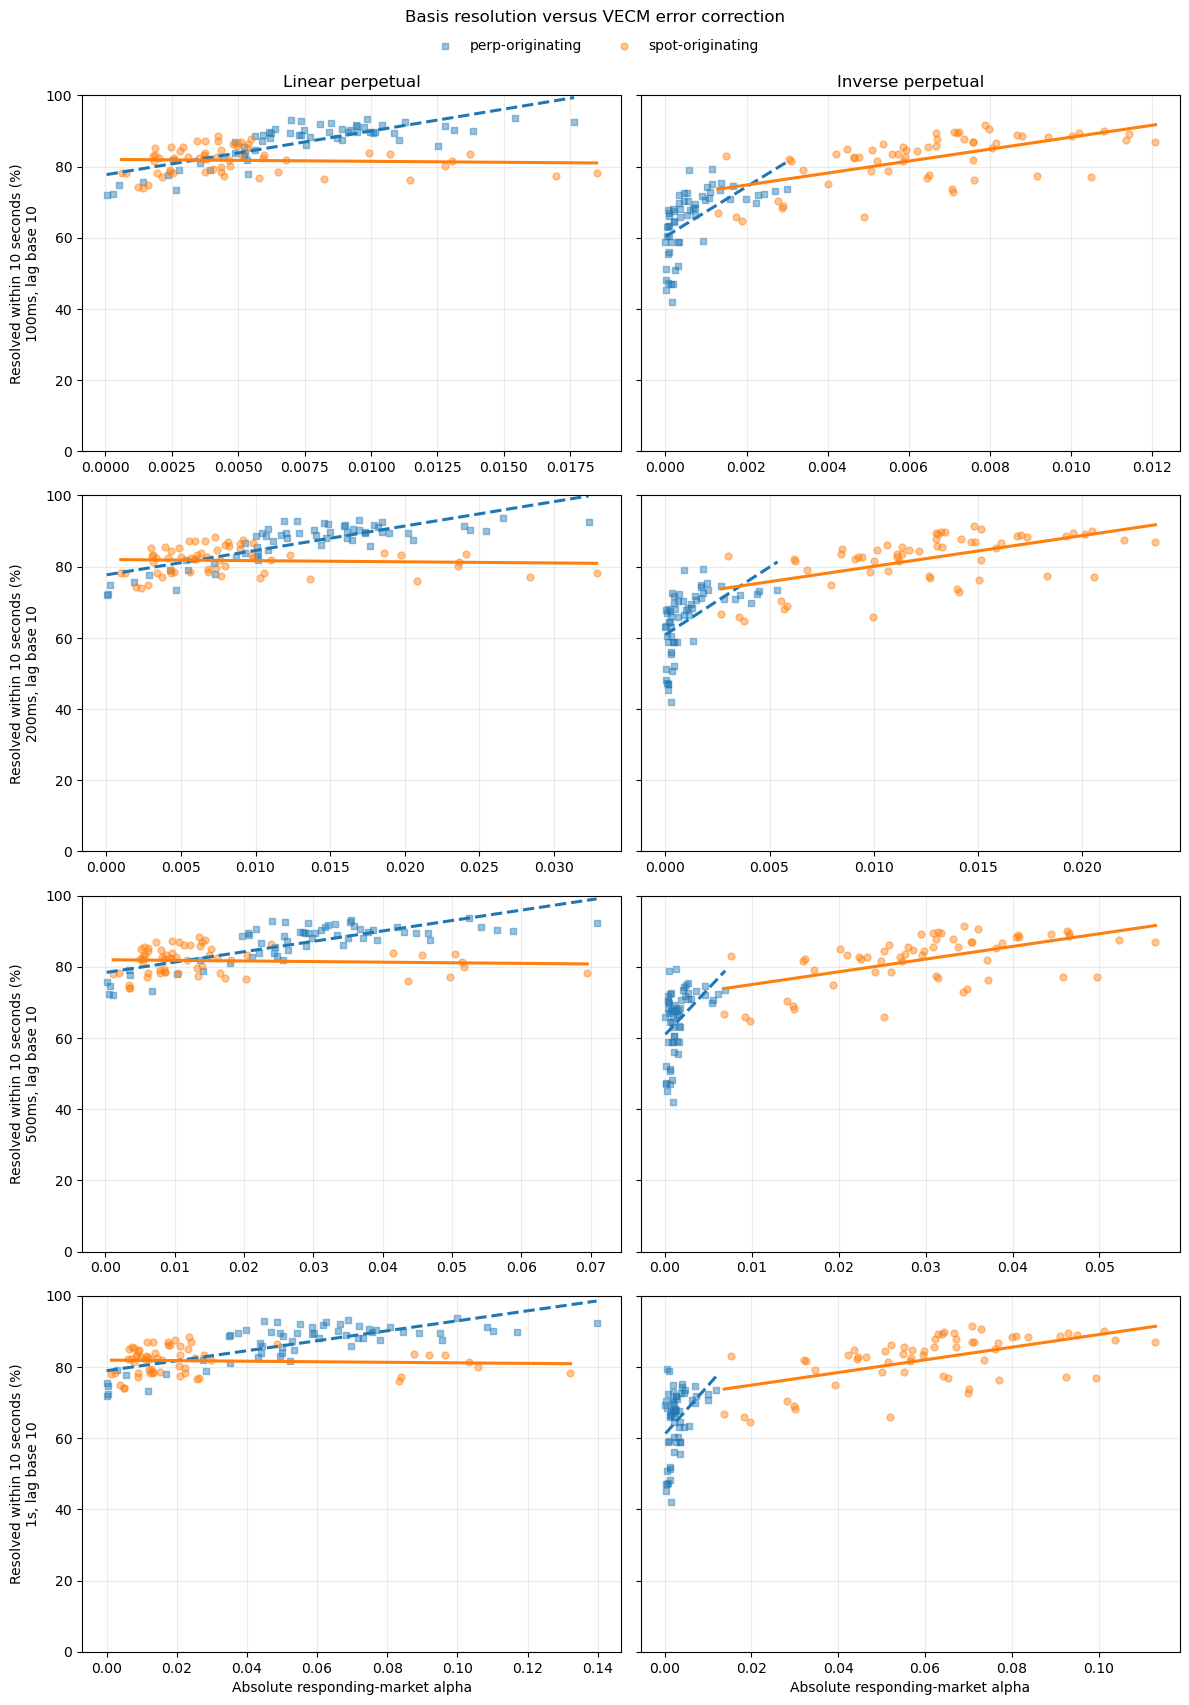

In [31]:

fig, axes = plot_vecm_combinations_grid(
    comparison_all,
    combinations=available_combinations,
)

In [37]:
for latency in sorted_latencies:
    subset = comparison_all[
        comparison_all["contract_type"].eq("linear")
        & comparison_all["first"].eq("spot")
        & comparison_all["latency"].eq(latency)
    ].copy()

    print(
        latency,
        subset[
            ["abs_responding_alpha", "resolved_percent"]
        ].corr(method="spearman").iloc[0, 1]
    )

NameError: name 'sorted_latencies' is not defined

In [38]:
comparison_all["year"] = pd.to_datetime(
    comparison_all["period"]
).dt.year

yearly_corr = (
    comparison_all[
        comparison_all["contract_type"].eq("linear")
        & comparison_all["first"].eq("spot")
    ]
    .groupby(["latency", "year"])
    .apply(
        lambda g: g[
            ["abs_responding_alpha", "resolved_percent"]
        ].corr(method="spearman").iloc[0, 1]
    )
    .rename("spearman_corr")
    .reset_index()
)

In [39]:
yearly_corr

,latency,year,spearman_corr
0,100ms,2021,0.251748
1,100ms,2022,-0.370629
2,100ms,2023,-0.594406
3,100ms,2024,-0.370629
4,100ms,2025,-0.762238
5,10ms,2021,0.279720
6,10ms,2022,-0.174825
7,10ms,2023,-0.440559
8,10ms,2024,-0.468531
9,10ms,2025,-0.839161


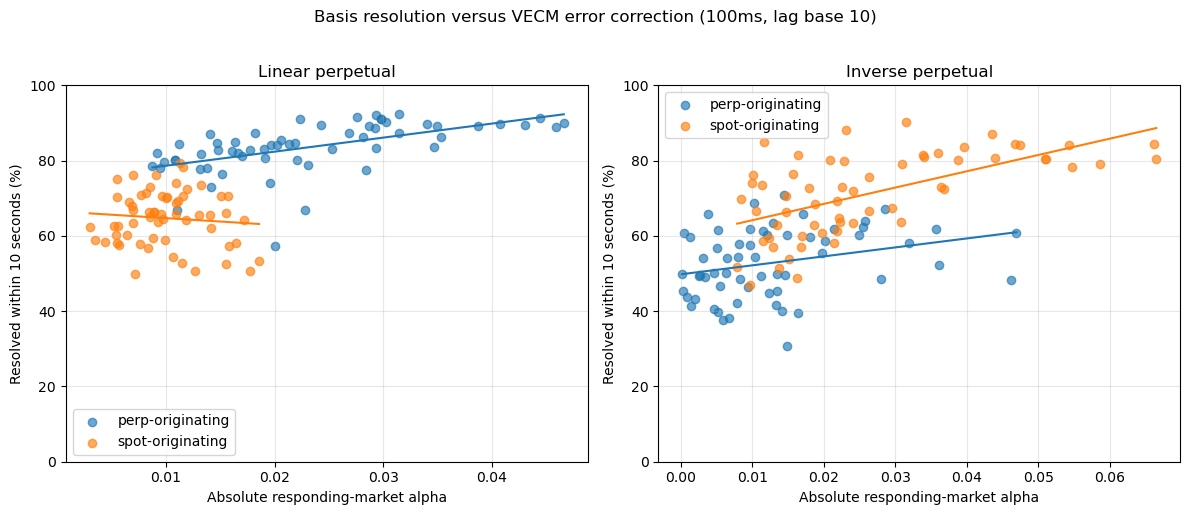

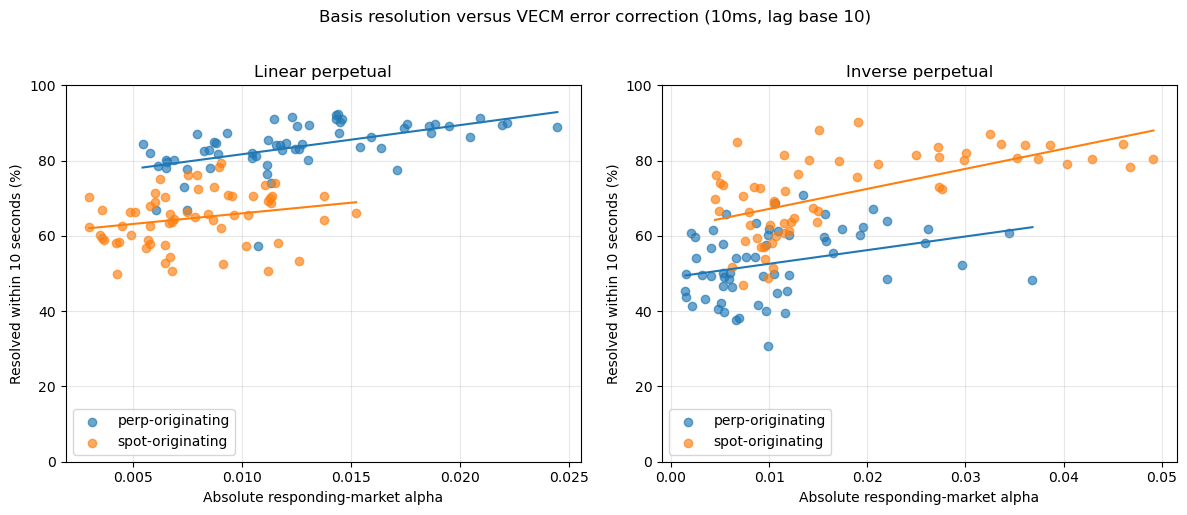

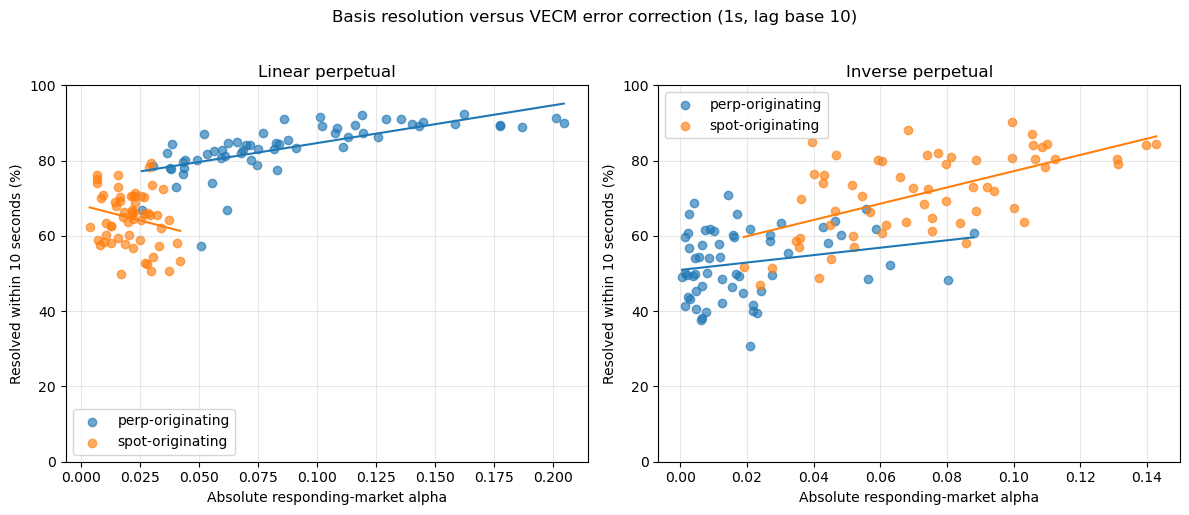

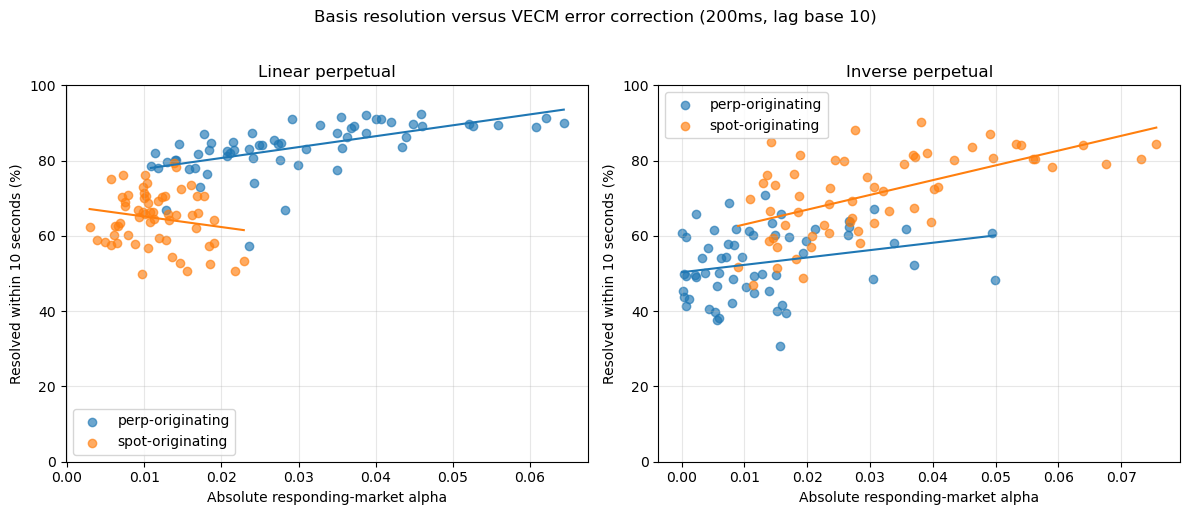

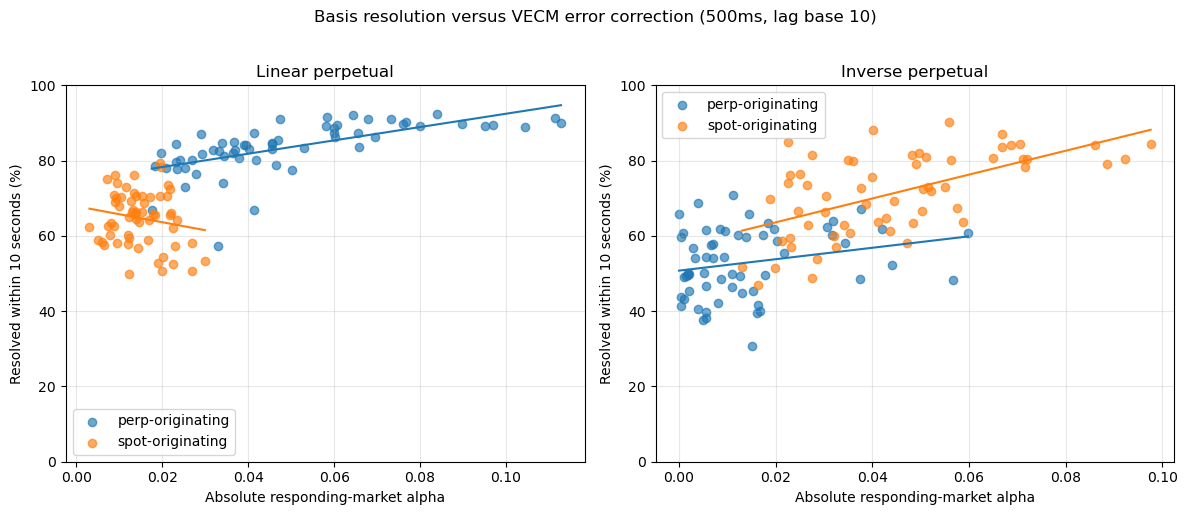

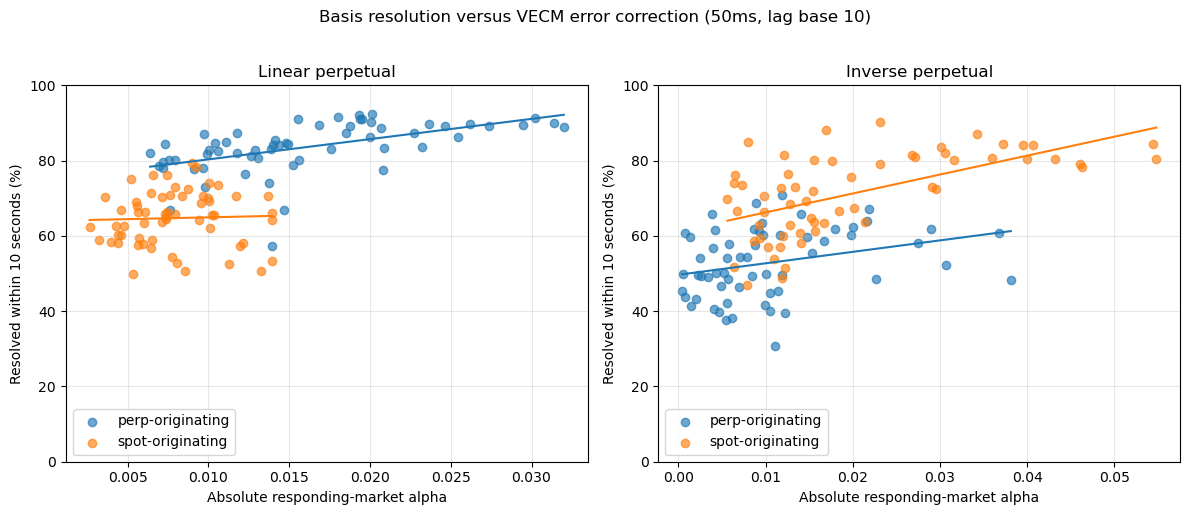

In [23]:
def plot_one_vecm_combination(comparison, latency, lag_base):
    data = comparison[
        comparison["latency"].eq(latency)
        & comparison["lag_base"].eq(lag_base)
    ].dropna(
        subset=["abs_responding_alpha", "resolved_percent"]
    ).copy()

    if data.empty:
        print(f"No merged data for {(latency, lag_base)}")
        return

    contract_types = [
        c for c in ["linear", "inverse"]
        if c in data["contract_type"].unique()
    ]

    fig, axes = plt.subplots(
        1, len(contract_types),
        figsize=(6 * len(contract_types), 5),
        squeeze=False,
    )

    for axis, contract_type in zip(axes[0], contract_types):
        contract_data = data[
            data["contract_type"].eq(contract_type)
        ]

        for first, group in contract_data.groupby("first", observed=True):
            axis.scatter(
                group["abs_responding_alpha"],
                group["resolved_percent"],
                alpha=0.65,
                label=f"{first}-originating",
            )

            valid = group[
                ["abs_responding_alpha", "resolved_percent"]
            ].dropna()

            if len(valid) >= 3:
                slope, intercept = np.polyfit(
                    valid["abs_responding_alpha"],
                    valid["resolved_percent"],
                    1,
                )
                x = np.linspace(
                    valid["abs_responding_alpha"].min(),
                    valid["abs_responding_alpha"].max(),
                    100,
                )
                axis.plot(x, intercept + slope * x)

        axis.set_title(f"{contract_type.capitalize()} perpetual")
        axis.set_xlabel("Absolute responding-market alpha")
        axis.set_ylabel("Resolved within 10 seconds (%)")
        axis.set_ylim(0, 100)
        axis.grid(alpha=0.3)
        axis.legend()

    fig.suptitle(
        "Basis resolution versus VECM error correction "
        f"({latency}, lag base {lag_base})",
        y=1.02,
    )
    fig.tight_layout()
    plt.show()


for latency, lag_base in available_combinations:
    plot_one_vecm_combination(
        comparison_all,
        latency,
        lag_base,
    )

## 11. Correlations for every combination

In [24]:
def correlation_summary_all(comparison):
    rows = []

    for keys, group in comparison.groupby(
        ["contract_type", "first", "latency", "lag_base"],
        observed=True,
    ):
        valid = group[
            ["abs_responding_alpha", "resolved_share"]
        ].replace([np.inf, -np.inf], np.nan).dropna()

        if len(valid) < 3:
            continue

        pearson_r, pearson_p = pearsonr(
            valid["abs_responding_alpha"],
            valid["resolved_share"],
        )
        spearman_rho, spearman_p = spearmanr(
            valid["abs_responding_alpha"],
            valid["resolved_share"],
        )

        rows.append({
            "contract_type": keys[0],
            "first": keys[1],
            "latency": keys[2],
            "lag_base": keys[3],
            "n_months": len(valid),
            "pearson_r": pearson_r,
            "pearson_p": pearson_p,
            "spearman_rho": spearman_rho,
            "spearman_p": spearman_p,
        })

    return pd.DataFrame(rows)


correlations_all = correlation_summary_all(comparison_all)

correlations_all.sort_values(
    ["contract_type", "first", "lag_base", "latency"]
)

,contract_type,first,latency,lag_base,n_months,pearson_r,pearson_p,spearman_rho,spearman_p
0,inverse,perp,100ms,10,60,0.285824,2.684161e-02,0.317088,1.356610e-02
1,inverse,perp,10ms,10,60,0.323749,1.162417e-02,0.370325,3.585427e-03
2,inverse,perp,1s,10,60,0.218497,9.350409e-02,0.198500,1.284103e-01
3,inverse,perp,200ms,10,60,0.252629,5.148611e-02,0.272353,3.527055e-02
4,inverse,perp,500ms,10,60,0.233139,7.302193e-02,0.240011,6.473120e-02
5,inverse,perp,50ms,10,60,0.294919,2.216559e-02,0.317088,1.356610e-02
6,inverse,spot,100ms,10,60,0.606071,2.873600e-07,0.613337,1.888146e-07
7,inverse,spot,10ms,10,60,0.608535,2.495087e-07,0.614171,1.798113e-07
8,inverse,spot,1s,10,60,0.596400,4.945740e-07,0.567602,2.252463e-06
9,inverse,spot,200ms,10,60,0.598908,4.303613e-07,0.589330,7.274274e-07


## 12. Plot how the relationship changes across latency

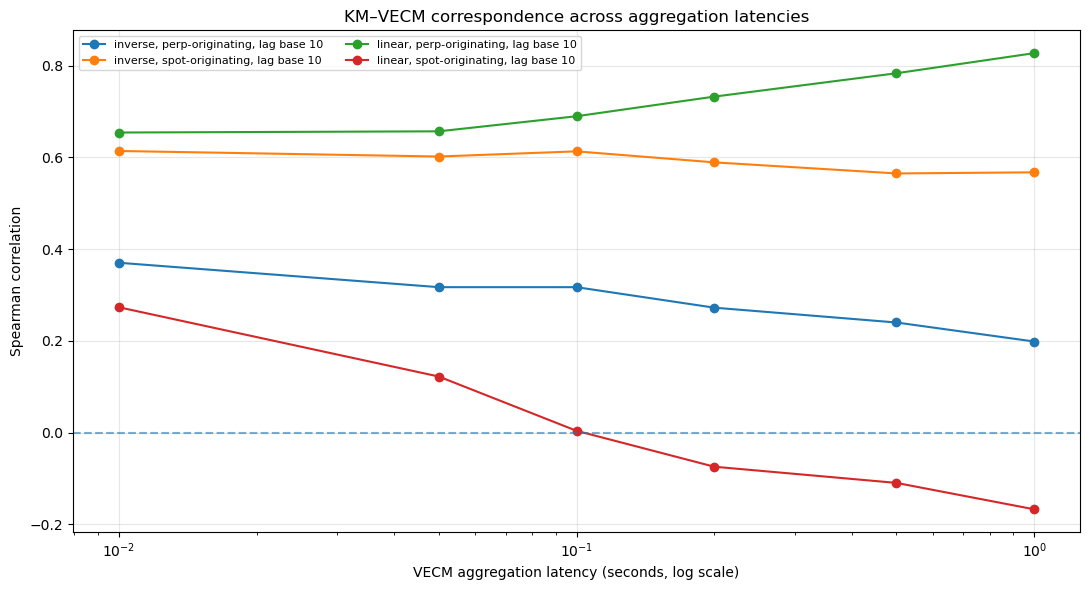

In [25]:
def latency_to_seconds(latency):
    latency = str(latency).lower().strip()
    if latency.endswith("ms"):
        return float(latency[:-2]) / 1000
    if latency.endswith("s"):
        return float(latency[:-1])
    raise ValueError(f"Unsupported latency: {latency}")


def plot_correlations_across_latency(correlations):
    data = correlations.copy()
    data["latency_seconds"] = data["latency"].map(
        latency_to_seconds
    )

    fig, ax = plt.subplots(figsize=(11, 6))

    for keys, group in data.groupby(
        ["contract_type", "first", "lag_base"],
        observed=True,
    ):
        group = group.sort_values("latency_seconds")
        ax.plot(
            group["latency_seconds"],
            group["spearman_rho"],
            marker="o",
            label=(
                f"{keys[0]}, {keys[1]}-originating, "
                f"lag base {keys[2]}"
            ),
        )

    ax.axhline(0, linestyle="--", alpha=0.6)
    ax.set_xscale("log")
    ax.set_xlabel("VECM aggregation latency (seconds, log scale)")
    ax.set_ylabel("Spearman correlation")
    ax.set_title(
        "KM–VECM correspondence across aggregation latencies"
    )
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, ncol=2)
    fig.tight_layout()
    plt.show()


plot_correlations_across_latency(correlations_all)

## 13. Heatmaps across latency and lag base

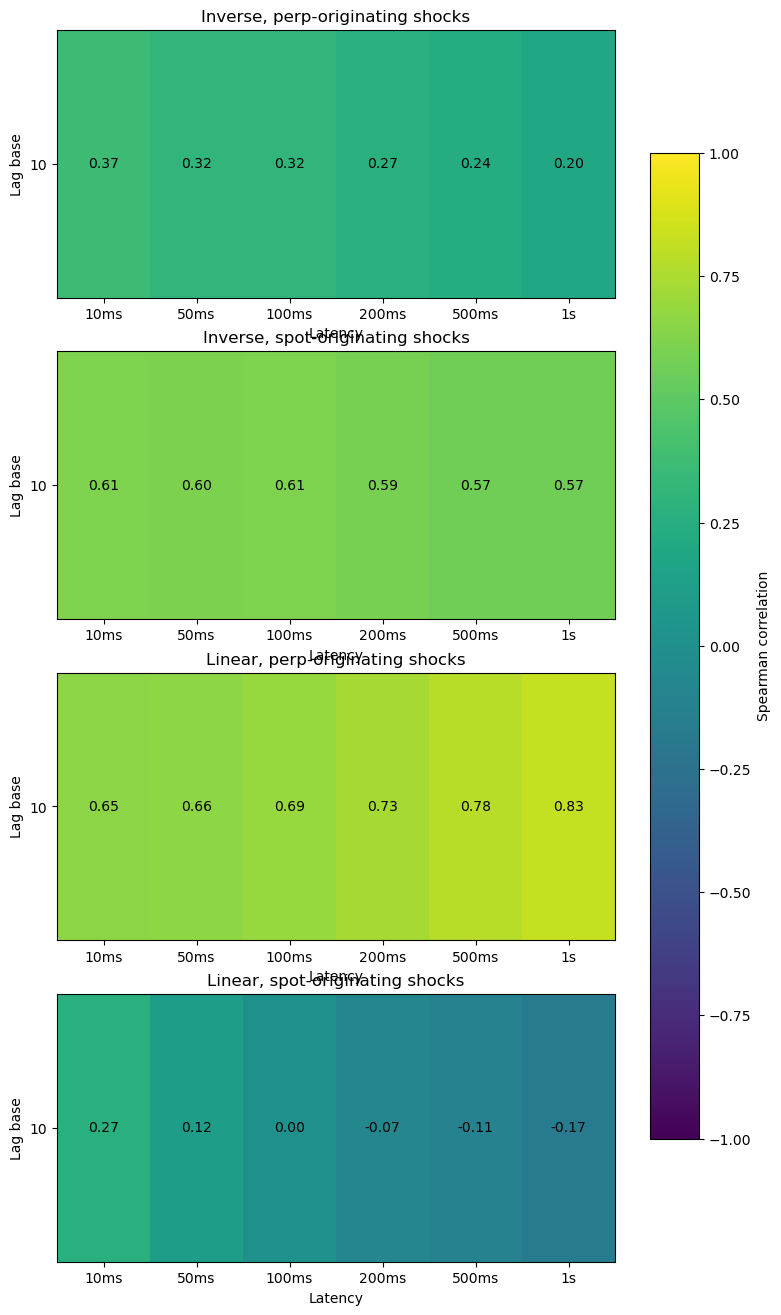

In [26]:
def plot_correlation_heatmaps(correlations):
    data = correlations.copy()
    latency_order = sorted(
        data["latency"].unique(),
        key=latency_to_seconds,
    )
    lag_order = sorted(data["lag_base"].unique())

    groups = list(
        data[["contract_type", "first"]]
        .drop_duplicates()
        .itertuples(index=False, name=None)
    )

    fig, axes = plt.subplots(
        len(groups), 1,
        figsize=(9, 4 * len(groups)),
        squeeze=False,
    )

    for axis, (contract_type, first) in zip(
        axes[:, 0], groups
    ):
        subset = data[
            data["contract_type"].eq(contract_type)
            & data["first"].eq(first)
        ]

        pivot = subset.pivot(
            index="lag_base",
            columns="latency",
            values="spearman_rho",
        ).reindex(
            index=lag_order,
            columns=latency_order,
        )

        image = axis.imshow(
            pivot.to_numpy(dtype=float),
            aspect="auto",
            vmin=-1,
            vmax=1,
        )

        axis.set_title(
            f"{contract_type.capitalize()}, "
            f"{first}-originating shocks"
        )
        axis.set_xlabel("Latency")
        axis.set_ylabel("Lag base")
        axis.set_xticks(range(len(pivot.columns)))
        axis.set_xticklabels(pivot.columns)
        axis.set_yticks(range(len(pivot.index)))
        axis.set_yticklabels(pivot.index)

        for r in range(len(pivot.index)):
            for c in range(len(pivot.columns)):
                value = pivot.iloc[r, c]
                if pd.notna(value):
                    axis.text(c, r, f"{value:.2f}",
                              ha="center", va="center")

    fig.colorbar(
        image,
        ax=axes[:, 0].tolist(),
        label="Spearman correlation",
        shrink=0.8,
    )
    plt.show()


plot_correlation_heatmaps(correlations_all)

## 14. Check alpha-sign validity

Taking an absolute value can make a wrong-sign coefficient appear to represent strong error correction. This diagnostic reports the share of months with the conventional responding-market sign:

- spot-originating shock: `alpha_perp > 0`;
- perp-originating shock: `alpha_spot < 0`.

In [27]:
comparison_all["conventional_responding_sign"] = np.where(
    comparison_all["first"].eq("spot"),
    comparison_all["alpha_perp"].gt(0),
    comparison_all["alpha_spot"].lt(0),
)

sign_summary = (
    comparison_all.groupby(
        ["contract_type", "first", "latency", "lag_base"],
        observed=True,
    )["conventional_responding_sign"]
    .agg(
        conventional_sign_share="mean",
        n_months="size",
    )
    .reset_index()
)

sign_summary.sort_values(
    ["contract_type", "first", "lag_base", "latency"]
)

,contract_type,first,latency,lag_base,conventional_sign_share,n_months
0,inverse,perp,100ms,10,1.000000,60
1,inverse,perp,10ms,10,1.000000,60
2,inverse,perp,1s,10,0.850000,60
3,inverse,perp,200ms,10,0.966667,60
4,inverse,perp,500ms,10,0.850000,60
5,inverse,perp,50ms,10,1.000000,60
6,inverse,spot,100ms,10,1.000000,60
7,inverse,spot,10ms,10,1.000000,60
8,inverse,spot,1s,10,1.000000,60
9,inverse,spot,200ms,10,1.000000,60


## 15. Correlations using conventional-sign months only

In [28]:
comparison_conventional = comparison_all[
    comparison_all["conventional_responding_sign"]
].copy()

correlations_conventional = correlation_summary_all(
    comparison_conventional
)

correlations_conventional.sort_values(
    ["contract_type", "first", "lag_base", "latency"]
)

,contract_type,first,latency,lag_base,n_months,pearson_r,pearson_p,spearman_rho,spearman_p
0,inverse,perp,100ms,10,60,0.285824,2.684161e-02,0.317088,1.356610e-02
1,inverse,perp,10ms,10,60,0.323749,1.162417e-02,0.370325,3.585427e-03
2,inverse,perp,1s,10,51,0.219274,1.221070e-01,0.206516,1.459514e-01
3,inverse,perp,200ms,10,58,0.237715,7.236312e-02,0.257621,5.089481e-02
4,inverse,perp,500ms,10,51,0.237486,9.333757e-02,0.268869,5.641708e-02
5,inverse,perp,50ms,10,60,0.294919,2.216559e-02,0.317088,1.356610e-02
6,inverse,spot,100ms,10,60,0.606071,2.873600e-07,0.613337,1.888146e-07
7,inverse,spot,10ms,10,60,0.608535,2.495087e-07,0.614171,1.798113e-07
8,inverse,spot,1s,10,60,0.596400,4.945740e-07,0.567602,2.252463e-06
9,inverse,spot,200ms,10,60,0.598908,4.303613e-07,0.589330,7.274274e-07


## 16. Save outputs

In [29]:
OUTPUT_DIR = Path(
    "sa_results/km_v5_vecm_all_latency_lag_combinations"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

km_10s.to_csv(
    OUTPUT_DIR / "km_resolved_within_10s.csv",
    index=False,
)
vecm_monthly_all.to_csv(
    OUTPUT_DIR / "vecm_monthly_all_combinations.csv",
    index=False,
)
comparison_all.to_csv(
    OUTPUT_DIR / "km_vecm_comparison_all_combinations.csv",
    index=False,
)
correlations_all.to_csv(
    OUTPUT_DIR / "km_vecm_correlations_all_combinations.csv",
    index=False,
)
sign_summary.to_csv(
    OUTPUT_DIR / "responding_alpha_sign_summary.csv",
    index=False,
)
correlations_conventional.to_csv(
    OUTPUT_DIR / "km_vecm_correlations_conventional_sign_only.csv",
    index=False,
)

print("Saved outputs to:", OUTPUT_DIR.resolve())

Saved outputs to: C:\Users\Julia\OneDrive - University of Toronto\Desktop\School files\4th year\Thesis\Thesis-code\sa_results\km_v5_vecm_all_latency_lag_combinations


## Interpretation

This analysis holds the KM measure fixed and changes the VECM latency and lag specification. The cross-latency Spearman-correlation plot shows whether the within-specification ranking of months by VECM adjustment corresponds to the ranking by realized 10-second basis resolution.

Raw alpha magnitudes should not be compared directly across latencies because each alpha is measured per model observation.